In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from sklearn.datasets import load_diabetes 
import matplotlib.pyplot as plt
import numpy as np

from asa.correlation_methods import get_RF_importance, get_MI
from asa.dataset import Dataset

## Use dataset

In [3]:
data = load_diabetes()

dataset = Dataset(np.hstack((data.data, data.target[:, None])), data.feature_names + ['diabetes'])

In [4]:
dataset.get_RF_importance.__doc__

"\n        problem_type: str or None\n            'classification' or 'regression'\n            If None, try to guess\n\n        max_sample: int or None\n            The maximum number of samples used in the random forest\n            If None, unlimited\n\n        subsample: str or np.ndarray or None\n            If None, use all samples\n        \n        bad_treatment: str\n            'drop' or 'ignore'\n        \n        auto_balance: bool\n            If True, balance the class by random undersampling\n            It only works for classification\n        \n        check_res: bool\n            If True, print the train/test score\n        \n        return_more: bool\n            If True, return more results\n            IF False, only return feature_importance and score_test\n        "

Check the result:
  Train score:  0.9111204373715963
  Test score:  0.44578639027499567


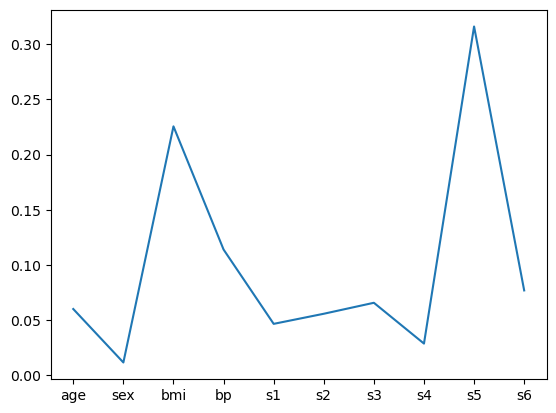

In [6]:
importance, score = dataset.get_RF_importance(
    ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'],
    'diabetes',
    problem_type='regression',
    RF_kwargs={
        'n_estimators': 1000,
        'max_depth': 10
    })

plt.plot(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], importance)


In [7]:
importance, score = dataset.get_RF_importance(
    ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'],
    'diabetes',
    problem_type='regression',
    RF_kwargs={
        'n_estimators': 100,
        'max_depth': 20
    },
    importance_type='permutation')

Check the result:
  Train score:  0.9223954294804904
  Test score:  0.37820649138017093


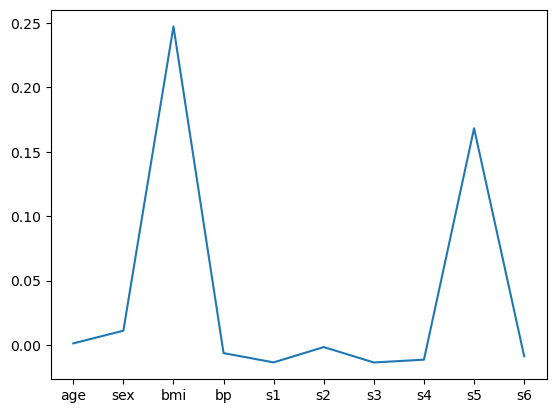

In [8]:
plt.plot(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'],
         importance.importances_mean)

## Use func

### RF

In [7]:
# generate regression data
data = load_diabetes()

In [10]:
x = data['data']
y = data['target']
x_label = data['feature_names']

In [4]:
feature_importance, rf, X_train, X_test, y_train, y_test = get_RF_importance(
    x,
    y,
    'regression',
    return_more=True,
    RF_kwargs={
        'n_estimators': 1000,
        'max_depth': 3,
        'random_state': 0
    })

In [42]:
rf.score(X_train, y_train)

0.5777904755852185

In [43]:
rf.score(X_test, y_test)

0.4917843594877097

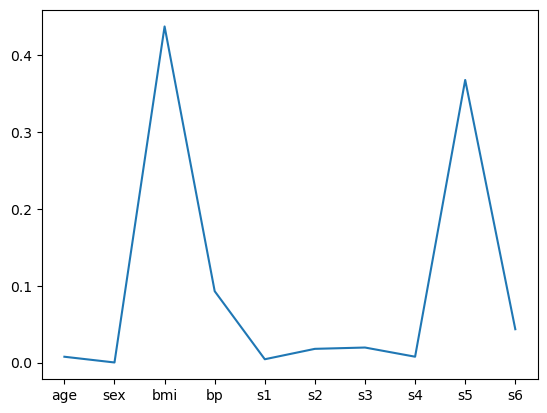

In [44]:
plt.plot(x_label, feature_importance)

In [45]:
feature_importance, rf, X_train, X_test, y_train, y_test = get_RF_importance(
    x, y, 'regression', return_more=True, importance_type='permutation')

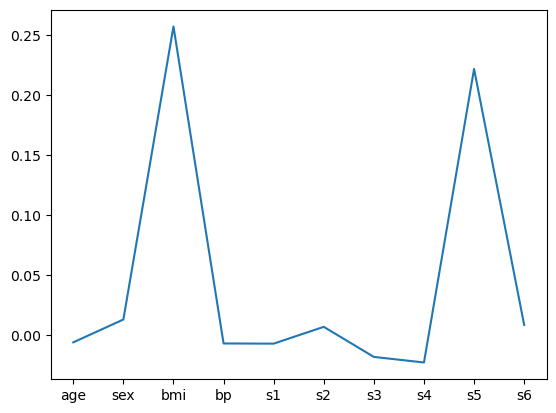

In [48]:
plt.plot(x_label, feature_importance.importances_mean)

### MI

In [3]:
data = load_diabetes()

x = data['data']
y = data['target']
x_label = data['feature_names']

In [5]:
x.shape

(442, 10)

In [22]:
get_MI(x[:, 2], y)

0.4438740661883944

In [17]:
get_MI(x[:, 2],
       y,
       is_qt=True,
       x_qt_kwargs={
           'n_quantiles': 100,
           'output_distribution': 'normal'
       },
       y_qt_kwargs={
           'n_quantiles': 100,
           'output_distribution': 'normal'
       })

0.2334246248051426

In [18]:
get_MI(x[:, 2],
       y,
       is_qt=True,
       robust=True,
       x_qt_kwargs={
           'n_quantiles': 100,
           'output_distribution': 'normal'
       },
       y_qt_kwargs={
           'n_quantiles': 100,
           'output_distribution': 'normal'
       })

(array([0.61898146]), array([1.39589798]), 0.24911382836734797)

In [21]:
get_MI(x[:, 2], y, robust=True)

(array([1.66035631]), array([0.70047688]), 0.4443265548763531)

In [25]:
get_MI(x[:, [2, 8]], y)

0.4520841483075628

In [26]:
get_MI(x[:, [2, 8]],
       y,
       is_qt=True,
       x_qt_kwargs={
           'n_quantiles': 100,
           'output_distribution': 'normal'
       },
       y_qt_kwargs={
           'n_quantiles': 100,
           'output_distribution': 'normal'
       })

0.31385969053399254

In [27]:
get_MI(x[:, [2, 8]],
       y,
       is_qt=True,
       robust=True,
       x_qt_kwargs={
           'n_quantiles': 100,
           'output_distribution': 'normal'
       },
       y_qt_kwargs={
           'n_quantiles': 100,
           'output_distribution': 'normal'
       })

(array([1.95578257, 0.806982  ]), array([0.88905323]), 0.34864293380365474)

In [28]:
get_MI(x[:, [2, 8]], y, robust=True)

(array([0.96107969, 1.5288059 ]), array([0.54198534]), 0.45566501889488187)